## Exploratory Modelling and Feature Analysis

This part is going to investigate the transformed electricity dataset to identify key features, 
patterns, or states that may inform the final model, or reveal changes that need to be addressed
in the main pipeline. 

In [1]:
import pandas as pd

df = pd.read_parquet("../data/processed/electricity_transformed.parquet")

### Inital Exploration

In [2]:
df.shape

(52800, 44)

In [3]:
df.head

<bound method NDFrame.head of                       timestamp  curtailment  curtailment_solar_utility  \
0     2020-09-15 00:00:00+10:00          0.0                        0.0   
1     2020-09-15 01:00:00+10:00          0.0                        0.0   
2     2020-09-15 02:00:00+10:00          0.0                        0.0   
3     2020-09-15 03:00:00+10:00          0.0                        0.0   
4     2020-09-15 04:00:00+10:00          0.0                        0.0   
...                         ...          ...                        ...   
52795 2026-09-23 19:00:00+10:00          0.0                        0.0   
52796 2026-09-23 20:00:00+10:00          0.0                        0.0   
52797 2026-09-23 21:00:00+10:00          0.0                        0.0   
52798 2026-09-23 22:00:00+10:00          0.0                        0.0   
52799 2026-09-23 23:00:00+10:00          0.0                        0.0   

       curtailment_wind       demand  demand_gross  flow_exports  \
0

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52800 entries, 0 to 52799
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   timestamp                              52800 non-null  datetime64[us, UTC+10:00]
 1   curtailment                            52800 non-null  float64                  
 2   curtailment_solar_utility              52800 non-null  float64                  
 3   curtailment_wind                       52800 non-null  float64                  
 4   demand                                 52800 non-null  float64                  
 5   demand_gross                           52800 non-null  float64                  
 6   flow_exports                           52800 non-null  float64                  
 7   flow_imports                           52800 non-null  float64                  
 8   generation_renewable                 

In [5]:
df.isna().sum()

timestamp                                0
curtailment                              0
curtailment_solar_utility                0
curtailment_wind                         0
demand                                   0
demand_gross                             0
flow_exports                             0
flow_imports                             0
generation_renewable                     0
generation_renewable_with_storage        0
price                                    0
renewable_proportion                     0
renewable_with_storage_proportion        0
emissions                                0
power                                    0
was_imputed                              0
curtailment_negative                     0
hour_sin                                 0
hour_cos                                 0
day_of_week_sin                          0
day_of_week_cos                          0
month_sin                                0
month_cos                                0
is_weekend 

In [6]:
df.columns.tolist()

['timestamp',
 'curtailment',
 'curtailment_solar_utility',
 'curtailment_wind',
 'demand',
 'demand_gross',
 'flow_exports',
 'flow_imports',
 'generation_renewable',
 'generation_renewable_with_storage',
 'price',
 'renewable_proportion',
 'renewable_with_storage_proportion',
 'emissions',
 'power',
 'was_imputed',
 'curtailment_negative',
 'hour_sin',
 'hour_cos',
 'day_of_week_sin',
 'day_of_week_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 'price_lag_1h',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'demand_lag_1h',
 'demand_lag_24h',
 'demand_lag_168h',
 'demand_rolling_mean_24h',
 'demand_rolling_std_24h',
 'generation_renewable_lag_1h',
 'generation_renewable_lag_24h',
 'generation_renewable_lag_168h',
 'generation_renewable_rolling_mean_24h',
 'generation_renewable_rolling_std_24h',
 'curtailment_lag_1h',
 'curtailment_lag_24h',
 'curtailment_lag_168h',
 'curtailment_rolling_mean_24h',
 'curtailment_rolling_std_24h']

### Seperating Feature Groups

In [7]:
# Core features
core_features = [
    "curtailment",
    "curtailment_solar_utility",
    "curtailment_wind",
    "demand",
    "demand_gross",
    "flow_exports",
    "flow_imports",
    "generation_renewable",
    "generation_renewable_with_storage",
    "price",
    "renewable_proportion",
    "renewable_with_storage_proportion",
    "emissions",
    "power"
]

# Time-based features
time_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "is_weekend"
]

# Data quality features
quality_flags = [
    "was_imputed",
    "curtailment_negative"
]

# Lagged features
lag_features = [
    "price_lag_1h",
    "price_lag_24h",
    "price_lag_168h",
    "demand_lag_1h",
    "demand_lag_24h",
    "demand_lag_168h",
    "generation_renewable_lag_1h",
    "generation_renewable_lag_24h",
    "generation_renewable_lag_168h",
    "curtailment_lag_1h",
    "curtailment_lag_24h",
    "curtailment_lag_168h"
]

# Rolling features
rolling_features = [
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
    "demand_rolling_mean_24h",
    "demand_rolling_std_24h",
    "generation_renewable_rolling_mean_24h",
    "generation_renewable_rolling_std_24h",
    "curtailment_rolling_mean_24h",
    "curtailment_rolling_std_24h"
]

timestamp_col = "timestamp"

### Investigating Core Features

In [8]:
X = df[core_features].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
curtailment,52800.0,106.329910,278.784519,-65.397000,0.000000,0.033100,70.840017,3503.327600
curtailment_solar_utility,52800.0,93.339836,249.393985,-65.397000,0.000000,0.000000,50.607098,3318.139467
curtailment_wind,52800.0,12.990074,51.534974,-25.700983,0.000000,0.000000,0.389833,1314.630875
demand,52800.0,7524.840933,1365.634929,2577.155833,6589.504166,7399.240833,8292.109375,13641.368333
demand_gross,52800.0,8613.144084,1516.777145,5411.577608,7455.836335,8550.551850,9573.128812,16134.240858
flow_exports,52800.0,151.195615,207.319850,0.000000,0.000000,47.823967,247.912883,1546.858323
flow_imports,52800.0,745.377861,411.946338,0.000000,448.290304,736.492139,1020.767551,2522.498118
generation_renewable,52800.0,2601.494633,2028.636065,26.355308,1065.931323,1786.491033,3807.208209,10898.422467
generation_renewable_with_storage,52800.0,2742.933349,2071.721107,26.355308,1176.059590,1967.275779,3911.019604,11477.422475
price,52800.0,109.136487,307.248261,-328.295833,45.723436,76.186250,117.703958,16157.503333


The variation in scales highlights the neede for scaling. From this we can also tell:
- cultailment, curtailment_solar_utility, and curtailment_wind are right skewed 
- price indicates major pricce spikes with the max of 16158
- demand is more stable

These high observations are not neccessarily outliers, but rather indicators of extreme operating conditions.

### Feature Relationships

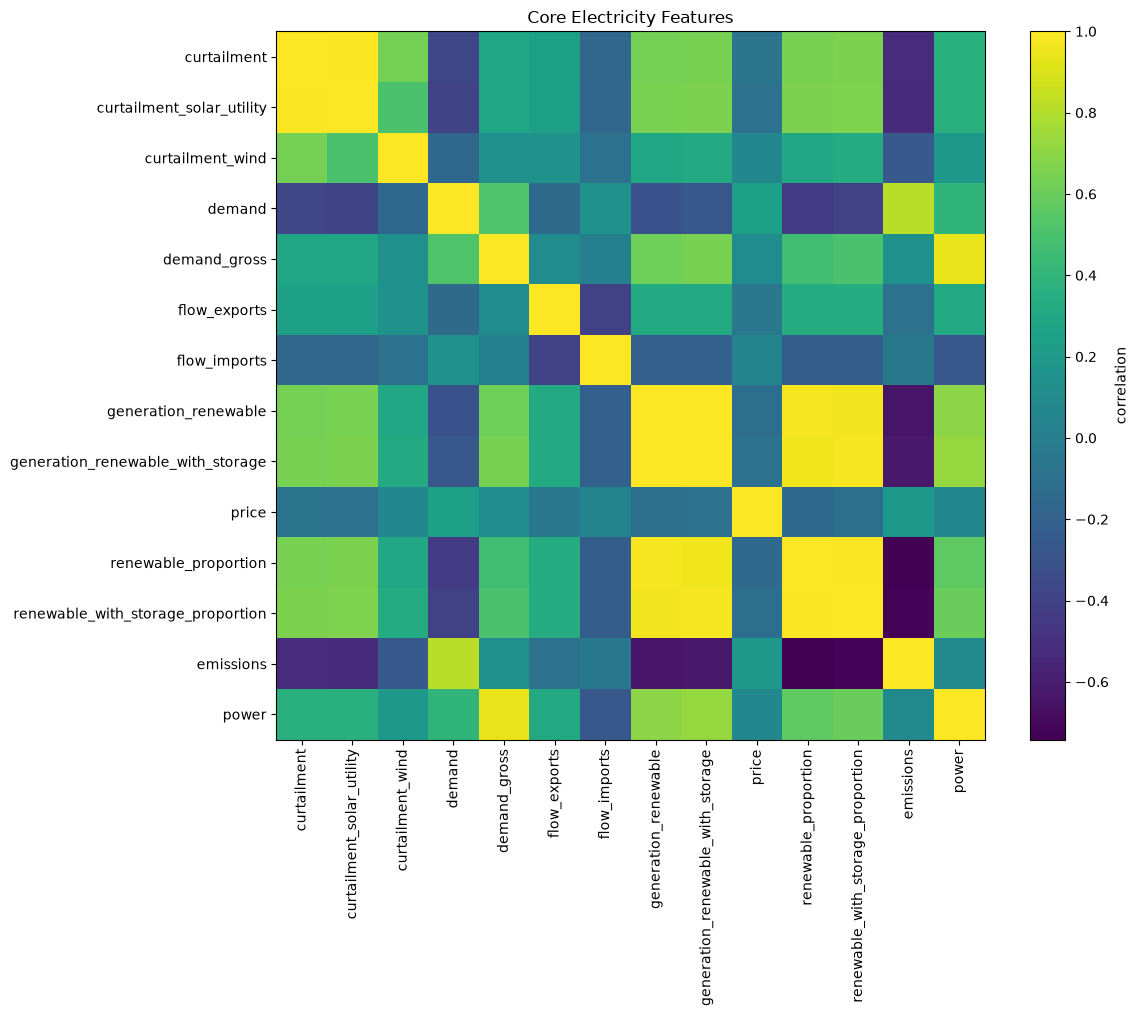

In [9]:
correlation_matrix = X.corr()

correlation_matrix.round(2)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix)

plt.colorbar(label="correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Core Electricity Features")
plt.tight_layout()
plt.show()

this higlights very high correlation, and therefore redundancies between:
- generation_renerable and generation_renewable_with_storage
- renewable_proportion and renewable_with_storage_proportion
- demand_gross and power
- curtaliment and curtailment_solar_utility

To prevent recounting the same system behaviour, it would be cleaner to limit some of these crossovers. 

In [10]:
selected_features = [
    "curtailment",
    "curtailment_wind",
    "demand",
    "flow_exports",
    "flow_imports",
    "generation_renewable",
    "price",
    "renewable_proportion",
    "emissions"
]

### Feature Scaing

In [11]:
from sklearn.preprocessing import StandardScaler

selected_features = [
    "curtailment",
    "curtailment_wind",
    "demand",
    "flow_exports",
    "flow_imports",
    "generation_renewable",
    "price",
    "renewable_proportion",
    "emissions"
]

X_selected = df[selected_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [12]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=df.index
)

In [13]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
curtailment,52800.0,1.033517e-16,1.000009,-0.615990,-0.381409,-0.381290,-0.127303,12.185145
curtailment_wind,52800.0,-1.722528e-17,1.000009,-0.750780,-0.252066,-0.252066,-0.244501,25.257665
demand,52800.0,3.229740e-16,1.000009,-3.623027,-0.684916,-0.091973,0.561845,4.478932
flow_exports,52800.0,8.612639e-17,1.000009,-0.729294,-0.729294,-0.498614,0.466517,6.731994
flow_imports,52800.0,-1.291896e-17,1.000009,-1.809422,-0.721187,-0.021570,0.668515,4.314001
generation_renewable,52800.0,3.445056e-17,1.000009,-1.269406,-0.756951,-0.401753,0.594353,4.089943
price,52800.0,-1.076580e-17,1.000009,-1.423723,-0.206392,-0.107244,0.027885,52.233066
renewable_proportion,52800.0,-1.894781e-16,1.000009,-1.470619,-0.775103,-0.353641,0.651223,3.510624
emissions,52800.0,-1.033517e-16,1.000009,-2.862387,-0.623821,0.045515,0.694821,3.003498


this just validates that the scaler has worked.

### PCA

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print(explained_variance)
print(cumulative_variance)

[0.43042106 0.15465752 0.1330862  0.09341985 0.08753504 0.06512519
 0.02918495 0.00520516 0.00136503]
[0.43042106 0.58507857 0.71816478 0.81158463 0.89911967 0.96424485
 0.99342981 0.99863497 1.        ]


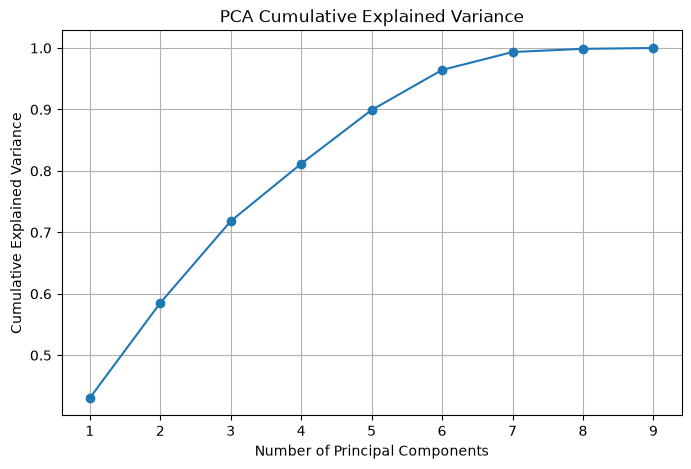

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)

plt.show()

this shows us that the 9 selected features can be represented with 5 principals components whilst keeping 90% variance (ish) basically just for how i decided how many components to use for my first k-means run.

In [16]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

### selecting cluster amount

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_pca, labels)
    )

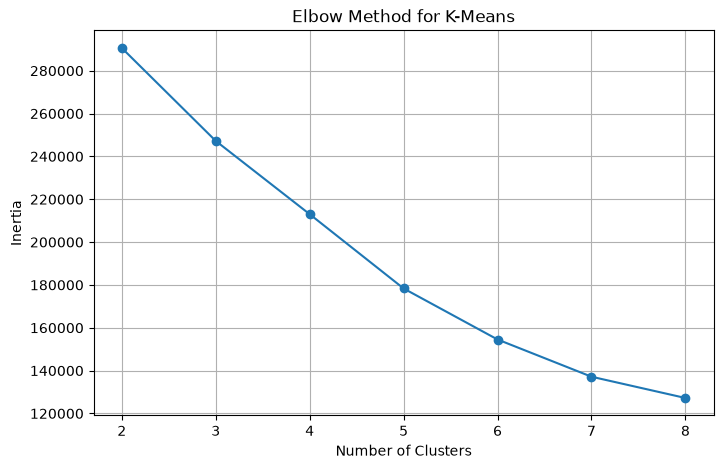

In [18]:
# elbow 

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

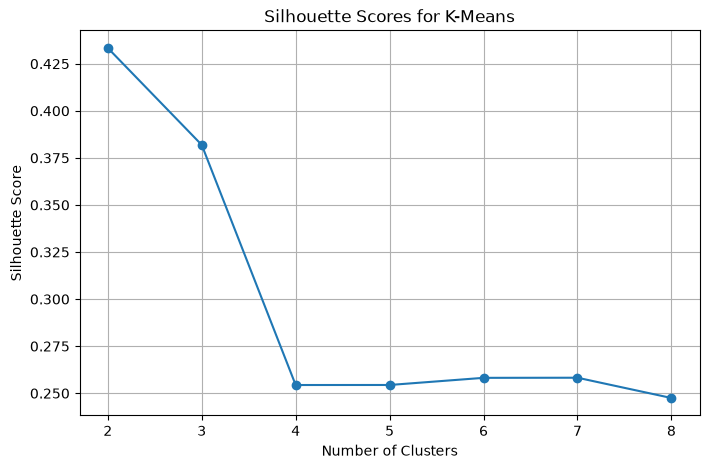

In [19]:
# silhouette

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.grid(True)
plt.show()

hmmm a bit ambiguous, let's go with 3, before the silhouette drop, although 2 clusters is the best, a two way split is a bit limited for distingishing states n stuff.

In [21]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_pca)

In [22]:
df["cluster"] = cluster_labels

df["cluster"].value_counts().sort_index()

cluster
0    12877
1    38511
2     1412
Name: count, dtype: int64

so what do these clusters indicate?

In [23]:
cluster_profiles = df.groupby("cluster")[selected_features].mean()

cluster_profiles.round(2)

,curtailment,curtailment_wind,demand,flow_exports,flow_imports,generation_renewable,price,renewable_proportion,emissions
cluster,,,,,,,,,
0,250.68,14.51,6690.74,233.06,633.97,5207.40,47.20,54.24,3503.19
1,13.30,4.44,7877.69,115.30,791.88,1575.35,130.89,18.55,5245.69
2,1327.29,232.43,5508.07,383.75,493.16,6823.70,80.79,69.38,2512.66


hmmm

cluster 0: moderate demand, high renewabe generation, 54% renewable share, low price, lower emissions

cluster 1: highest demand, lowest renewable generation, highest imports, highest price, highest emissions (this matches the scenario we proposed)

cluster 2: low demand, high renewable gen, 69% renewable share, very high curtaliment, higher exports, lowest emissions. (this was the smallest one by a far lot, but still interesting to note)

let's visualise:

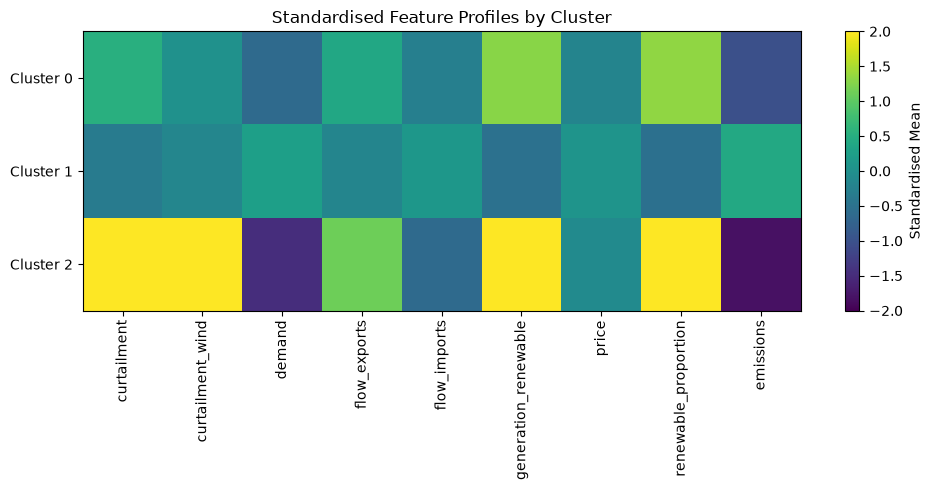

In [24]:
scaled_with_cluster = X_scaled.copy()
scaled_with_cluster["cluster"] = cluster_labels

scaled_cluster_profiles = (
    scaled_with_cluster
    .groupby("cluster")
    .mean()
)

scaled_cluster_profiles.round(2)

plt.figure(figsize=(10, 5))

plt.imshow(
    scaled_cluster_profiles,
    aspect="auto",
    vmin=-2,
    vmax=2
)

plt.colorbar(label="Standardised Mean")

plt.xticks(
    range(len(selected_features)),
    selected_features,
    rotation=90
)

plt.yticks(
    range(3),
    ["Cluster 0", "Cluster 1", "Cluster 2"]
)

plt.title("Standardised Feature Profiles by Cluster")
plt.tight_layout()
plt.show()

and now considering these clusters, based on time...

In [26]:
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month

cluster_by_hour = (
    df.groupby(["hour", "cluster"])
      .size()
      .unstack(fill_value=0)
)

cluster_by_hour

cluster,0,1,2
hour,,,
0,9,2191,0
1,18,2182,0
2,31,2169,0
3,40,2160,0
4,29,2171,0
5,24,2176,0
6,193,2006,1
7,586,1593,21
8,986,1135,79


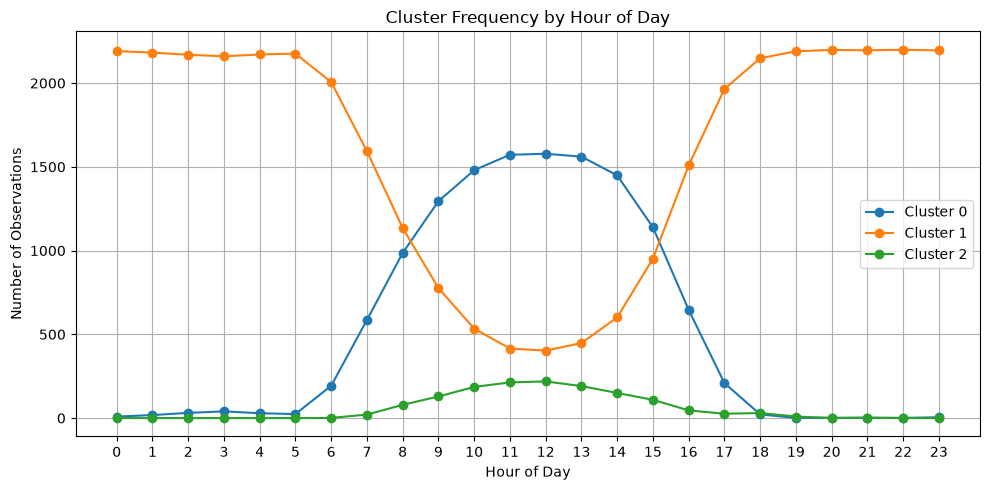

In [27]:
plt.figure(figsize=(10, 5))

for cluster in cluster_by_hour.columns:
    plt.plot(
        cluster_by_hour.index,
        cluster_by_hour[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.title("Cluster Frequency by Hour of Day")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

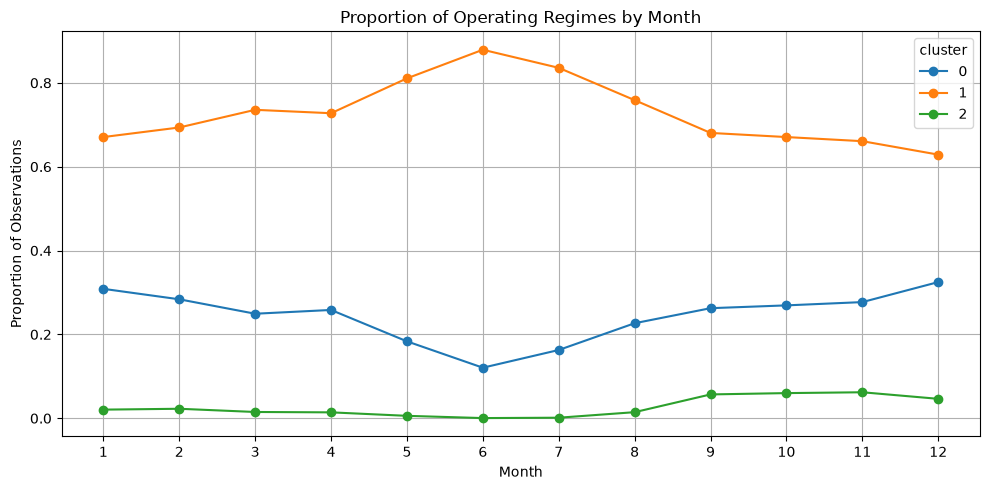

In [34]:
# this is proportion cause months have different days

cluster_month_prop = pd.crosstab(
    df["month"],
    df["cluster"],
    normalize="index"
)

cluster_month_prop.plot(
    figsize=(10, 5),
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Proportion of Observations")
plt.title("Proportion of Operating Regimes by Month")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

now checking for anomaly detection, gonna use isolation forest

# anomaly detection

In [39]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(X_scaled)

In [40]:
df["anomaly"] = anomaly_labels

df["anomaly"].value_counts()

anomaly
 1    51744
-1     1056
Name: count, dtype: int64

In [41]:
anomalies = df[df["anomaly"] == -1]

anomalies[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
curtailment,1056.0,1418.568918,665.722578,0.000000,983.623673,1438.937825,1838.742837,3503.327600
curtailment_wind,1056.0,228.118186,195.536828,0.000000,78.683373,185.809546,322.338718,1314.630875
demand,1056.0,5647.818987,2300.847367,2577.155833,4181.790208,4779.697084,6011.398125,13641.368333
flow_exports,1056.0,454.800273,387.984789,0.000000,61.515277,399.110233,786.517571,1546.858323
flow_imports,1056.0,488.915515,435.160263,0.000000,66.690689,425.625522,805.320321,2247.002565
generation_renewable,1056.0,6904.376427,2123.534057,579.932267,6010.709808,7394.015446,8329.773277,10732.672992
price,1056.0,404.506328,1726.358000,-278.141667,-35.128750,-16.183333,-1.509583,16157.503333
renewable_proportion,1056.0,68.794716,20.539928,5.150000,65.115000,75.940000,81.847500,96.250000
emissions,1056.0,2679.662681,1518.123042,1240.989800,1685.974900,2109.449700,2778.819750,7629.974200


In [42]:
anomaly_profile = (
    df.groupby("anomaly")[selected_features]
      .mean()
      .round(2)
)

anomaly_profile

,curtailment,curtailment_wind,demand,flow_exports,flow_imports,generation_renewable,price,renewable_proportion,emissions
anomaly,,,,,,,,,
-1,1418.57,228.12,5647.82,454.8,488.92,6904.38,404.51,68.79,2679.66
1,79.55,8.60,7563.15,145.0,750.61,2513.68,103.11,27.79,4789.84


In [44]:
# overlay with clusters...

pd.crosstab(
    df["cluster"],
    df["anomaly"]
)

anomaly,-1,1
cluster,,
0,93,12784
1,72,38439
2,891,521


*** CONTAMINATION IS AN ASSUMPTION

going to use RF model to sort of interpt which variables were most influential in distigushing the clusters discovered.

### Feature importance

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_selected, cluster_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [46]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

feature_importance

renewable_proportion    0.426310
generation_renewable    0.182564
curtailment             0.164396
emissions               0.080918
curtailment_wind        0.052927
demand                  0.034604
price                   0.031547
flow_exports            0.018813
flow_imports            0.007921
dtype: float64

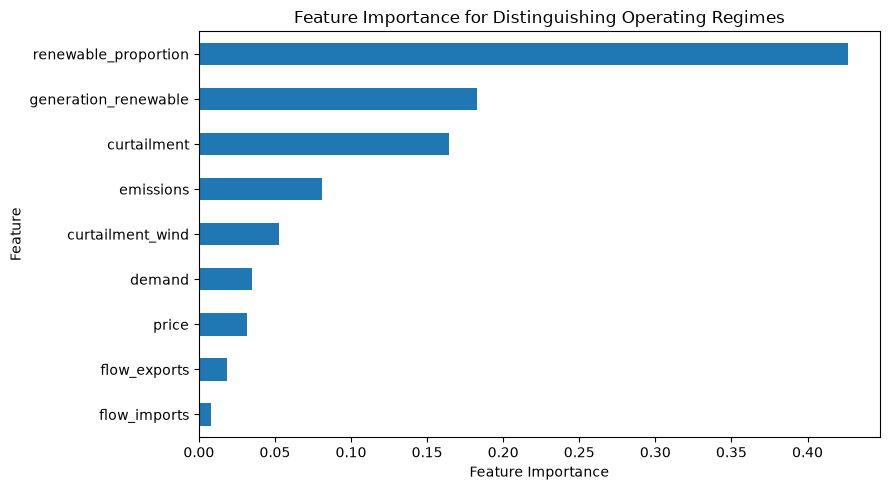

In [47]:
plt.figure(figsize=(9, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Distinguishing Operating Regimes")
plt.tight_layout()
plt.show()

In [48]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

pca_loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
curtailment,0.406,-0.113,0.310,0.234,-0.126
curtailment_wind,0.254,-0.216,0.533,0.567,-0.041
demand,-0.331,-0.362,0.232,-0.241,-0.576
flow_exports,0.202,-0.517,-0.329,-0.026,0.050
flow_imports,-0.143,0.538,0.422,-0.170,-0.267
generation_renewable,0.441,-0.070,0.028,-0.416,-0.297
price,-0.106,-0.296,0.529,-0.475,0.627
renewable_proportion,0.466,-0.014,-0.018,-0.360,-0.184
emissions,-0.421,-0.400,0.012,0.087,-0.250


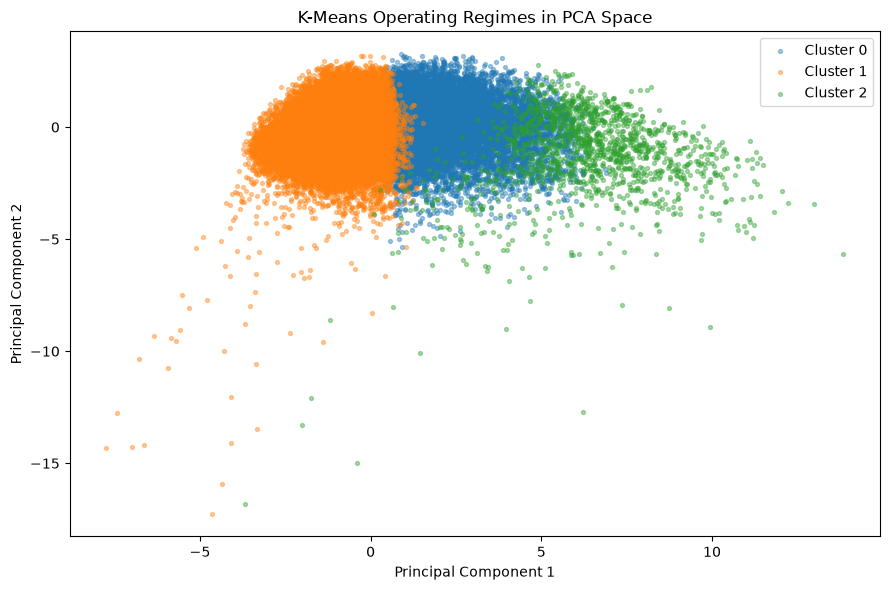

In [49]:
pca_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(9, 6))

for cluster in sorted(pca_plot["cluster"].unique()):
    subset = pca_plot[pca_plot["cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=8,
        alpha=0.4,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Operating Regimes in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

# Summary of Findings

There is mainly 3 clusters...
Cluster 0:
- moderate demand
- high renewable gen with 54% renewable share
- low price and emissions 
- this is a very balanced state

Cluster 1:
- high demand
- low reneable gen
- high imports
- high price
- high emissions
- this would be similar to the proposed network-stress scenario we discussed in the word doc. (high stress without me saying that it has been validated as high stress, as we have not really defined stress yet)

Cluster 2:
- low demand
- high renewable gen
- 69% renewables
- high curtailment
- high exports
- low emissions
very small cluster but important to recognise 

through anomaly detection, cluster 2 is viewed as an uncommon but reoccuring state.

temporal patterns:
- cluster 1: winter and overnight
- cluster 0 and 2: daylight hours

renewable proportion, generation, and curtailment were most influential. then emissions, demand, and price.

this confirms we need to consider a range of features, this also recognised the conditions of supply pressure and renewable surplus. these along with the identified features and clusters should be passed to our design, maybe. its more renewable focused than i expected.